<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/regfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Project- Group 17**

In [ ]:
!pip install pregress

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pregress as pr
import seaborn as sns
import pandas as pd

In [ ]:
# Load CSV
df = pd.read_csv("suspicious_tax_returns.csv")

# Quick preview
df.head(20)

,Reported_Income,Claimed_Deductions_Pct,Business_Expenses,Charitable_Contributions_Pct,Home_Office_Deduction,Num_Dependents,Amended_Returns,Tax_Credits,Investment_Income_Pct,Income_Variability_Pct,Years_Since_Last_Audit,Occupation,Tax_Adjustment_Amount
0,116129,9.8,41456.25,1.3,12436.875,1,0,5264.1284,9.5,8.10,10,Lawyer,8253
1,58059,18.5,22518.75,5.3,11755.625,0,0,2148.1830,13.3,6.12,15,Doctor,10785
2,85894,14.3,29248.50,5.9,8774.550,1,1,4635.5684,7.6,13.34,5,Doctor,12174
3,93986,17.5,36305.50,7.0,10891.650,0,0,4725.5100,10.8,16.72,15,Lawyer,21910
4,87128,18.1,27794.00,8.1,8338.200,2,0,5829.0336,8.8,18.32,10,Real Estate Agent,-2524
5,71816,15.0,33751.00,3.9,10125.300,2,0,3171.4800,13.6,17.54,5,Doctor,-20093
6,120346,14.5,43233.50,6.6,15970.050,1,0,4170.0340,12.5,32.50,3,Real Estate Agent,272
7,72160,17.0,30510.00,3.9,9153.000,2,0,6677.4400,6.3,12.42,10,Real Estate Agent,13546
8,135553,17.9,44244.25,5.6,13273.275,2,0,6609.7974,9.4,11.56,10,Doctor,27698
9,73119,14.9,33130.75,3.3,9939.225,1,0,4526.9462,7.7,4.78,10,Self-Employed,-3388


In [ ]:
# Fit model
model = pr.fit("Tax_Adjustment_Amount ~ .", data=df)

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Tax_Adjustment_Amount   R-squared:                       0.778
Model:                               OLS   Adj. R-squared:                  0.777
Method:                    Least Squares   F-statistic:                     580.6
Date:                   Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                           16:10:09   Log-Likelihood:                -28587.
No. Observations:                   2496   AIC:                         5.721e+04
Df Residuals:                       2480   BIC:                         5.730e+04
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [ ]:
# Ensure numeric types
numeric_cols = [
    "Reported_Income",
    "Claimed_Deductions_Pct",
    "Business_Expenses",
    "Charitable_Contributions_Pct",
    "Home_Office_Deduction",
    "Num_Dependents",
    "Amended_Returns",
    "Tax_Credits",
    "Investment_Income_Pct",
    "Income_Variability_Pct",
    "Years_Since_Last_Audit",
    "Tax_Adjustment_Amount"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows missing target
df = df.dropna(subset=["Tax_Adjustment_Amount"]).copy()

# Dummy variables for Occupation (categorical)
df_dummies = pd.get_dummies(df, columns=["Occupation"], drop_first=True)


$$$$
dummy variables

In [ ]:
df["Occ_Small_Business_Owner"] = (df["Occupation"] == "Small Business Owner").astype(int)


In [ ]:
# Drop baseline: Small Business Owner
df["Occ_Self_Employed"] = (df["Occupation"] == "Self-Employed").astype(int)
df["Occ_Doctor"] = (df["Occupation"] == "Doctor").astype(int)
df["Occ_Lawyer"] = (df["Occupation"] == "Lawyer").astype(int)
df["Occ_Real_Estate"] = (df["Occupation"] == "Real Estate Agent").astype(int)

df[["Occupation","Occ_Self_Employed","Occ_Doctor","Occ_Lawyer","Occ_Real_Estate", "Occ_Small_Business_Owner"]].head(28)



,Occupation,Occ_Self_Employed,Occ_Doctor,Occ_Lawyer,Occ_Real_Estate,Occ_Small_Business_Owner
0,Lawyer,0,0,1,0,0
1,Doctor,0,1,0,0,0
2,Doctor,0,1,0,0,0
3,Lawyer,0,0,1,0,0
4,Real Estate Agent,0,0,0,1,0
5,Doctor,0,1,0,0,0
6,Real Estate Agent,0,0,0,1,0
7,Real Estate Agent,0,0,0,1,0
8,Doctor,0,1,0,0,0
9,Self-Employed,1,0,0,0,0


In [ ]:
predictors = [
    "Reported_Income",
    "Claimed_Deductions_Pct",
    "Business_Expenses",
    "Charitable_Contributions_Pct",
    "Home_Office_Deduction",
    "Num_Dependents",
    "Amended_Returns",
    "Tax_Credits",
    "Investment_Income_Pct",
    "Income_Variability_Pct",
    "Years_Since_Last_Audit",
    "Occ_Self_Employed",
    "Occ_Doctor",
    "Occ_Lawyer",
    "Occ_Real_Estate",
    "Occ_Small_Business_Owner"
]

formula = "Tax_Adjustment_Amount ~ " + " + ".join(predictors)
print("Formula:\n", formula)


Formula:
 Tax_Adjustment_Amount ~ Reported_Income + Claimed_Deductions_Pct + Business_Expenses + Charitable_Contributions_Pct + Home_Office_Deduction + Num_Dependents + Amended_Returns + Tax_Credits + Investment_Income_Pct + Income_Variability_Pct + Years_Since_Last_Audit + Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_Real_Estate + Occ_Small_Business_Owner


In [ ]:
model = pr.fit(formula, data=df)
print(model.summary())


                              OLS Regression Results                             
Dep. Variable:     Tax_Adjustment_Amount   R-squared:                       0.778
Model:                               OLS   Adj. R-squared:                  0.777
Method:                    Least Squares   F-statistic:                     580.6
Date:                   Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                           16:10:10   Log-Likelihood:                -28587.
No. Observations:                   2496   AIC:                         5.721e+04
Df Residuals:                       2480   BIC:                         5.730e+04
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [ ]:
be = pr.step(formula, data = df)
pr.summary(be)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                coef   std err       t     P>|t|     
Intercept                  1049.9687  1864.942   0.563  0.573000     
Claimed_Deductions_Pct      158.6090   108.652   1.460  0.144000     
Business_Expenses             0.2968     0.122   2.423  0.015000    *
Home_Office_Deduction         1.2154     0.357   3.403  0.001000   **
Tax_Credits                   0.8246     0.396   2.082  0.037000    *
Income_Variability_Pct      121.7675    60.766   2.004  0.045000    *
Occ_Self_Employed        -22910.0000   912.175 -25.111  0.000000  ***
Occ_Doctor               -22260.0000   984.682 -22.611  0.000000  ***
Occ_Lawyer               -23030.0000   961.052 -23.963  0.000000  ***
Occ_Real_Estate          -23720.0000  1091.323 -21.731  0.000000  ***
Occ_Small_Business_Owner  92970.0000  1065.785  87.227  0.000000  ***

Model Statistics:
---------------------------------------

In [ ]:
sub = pr.bsr(formula, data=df)
pr.summary(sub)


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                 coef   std err       t     P>|t|     
Intercept                 -21900.0000  2254.141  -9.714  0.000000  ***
Claimed_Deductions_Pct       161.0807   108.513   1.484  0.138000     
Business_Expenses              0.2988     0.122   2.442  0.015000    *
Home_Office_Deduction          1.2093     0.357   3.389  0.001000   **
Tax_Credits                    0.8211     0.396   2.074  0.038000    *
Income_Variability_Pct       121.4906    60.716   2.001  0.046000    *
Occ_Small_Business_Owner  115900.0000  1253.925  92.425  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.7781                AIC: 57192.0336
Adj. R-squared: 0.7775           BIC: 57232.7907
F-statistic: 1454.46 on 6 and 2489 DF, p-value: 0.000000


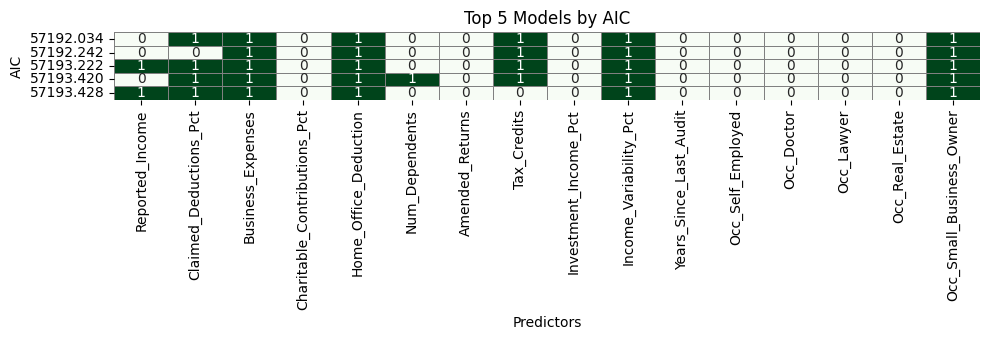

In [ ]:
pr.plot_bsr(sub)

In [ ]:
!pip install pregress

In [ ]:
import pregress as pr

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


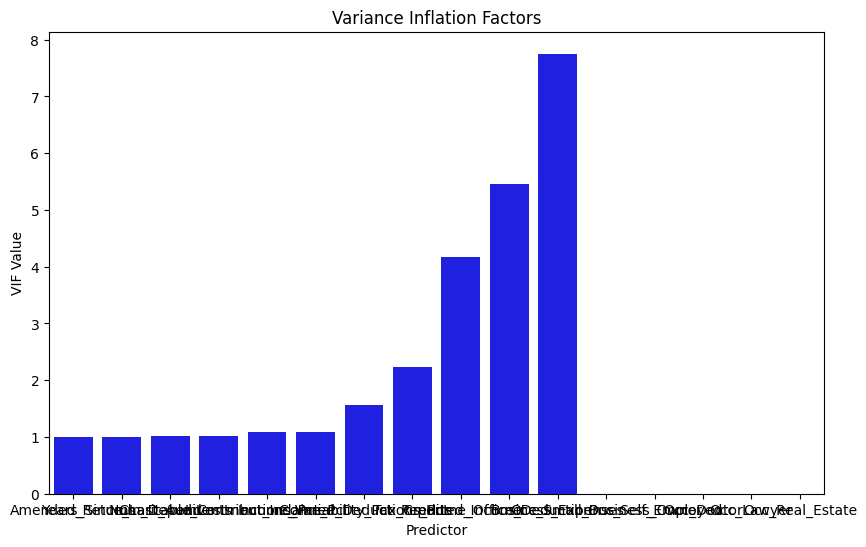

,Amended_Returns,Years_Since_Last_Audit,Num_Dependents,Charitable_Contributions_Pct,Investment_Income_Pct,Income_Variability_Pct,Claimed_Deductions_Pct,Tax_Credits,Reported_Income,Home_Office_Deduction,Business_Expenses,Occ_Small_Business_Owner,Occ_Self_Employed,Occ_Doctor,Occ_Lawyer,Occ_Real_Estate
VIF,1.003362,1.003612,1.006758,1.007953,1.076377,1.078139,1.554815,2.230298,4.172464,5.45273,7.75351,inf,inf,inf,inf,inf


In [ ]:
df_for_vif = df.drop(columns=['Occupation']).copy()
pr.vif("Tax_Adjustment_Amount ~ .", data=df_for_vif, plot = True)

$$$$
##Section 2:

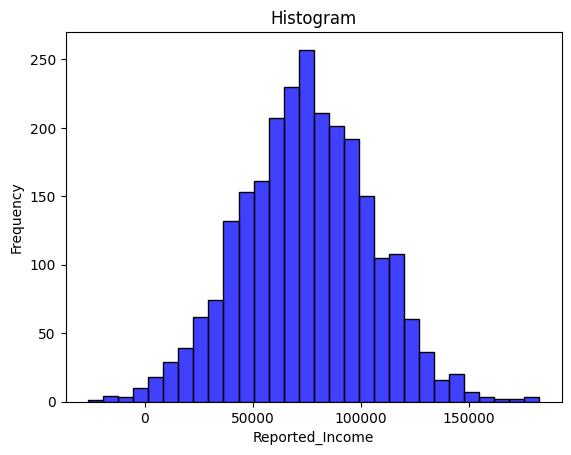

In [ ]:
pr.hist(df["Reported_Income"])

__Histogram of Reported Income__

The histogram of Reported_Income shows that most taxpayers earn between $50,000–$120,000, with the distribution roughly bell-shaped but slightly right-skewed. A small number of taxpayers report much higher incomes (> $150,000), which appear as outliers. This skewness suggests that while the dataset is balanced around typical middle-class incomes, extreme earners could heavily influence regression results. For this reason, log transformation of income may be considered in modeling.

$$$$$$$$


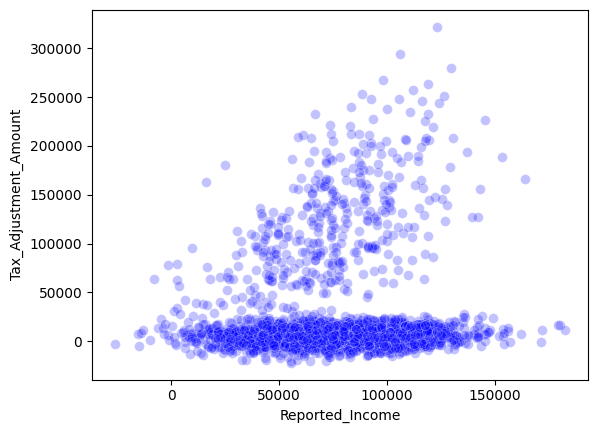

In [ ]:
pr.plot_xy("Tax_Adjustment_Amount ~ Reported_Income", data=df, alpha = 0.24, color="Occupation")

 __Claimed Deductions against Tax Adjustment Amount__
$$$$
The scatterplot of Claimed_Deductions_Pct against Tax_Adjustment_Amount highlights a clear pattern: higher deduction percentages are associated with larger IRS adjustments. While most taxpayers claim modest deductions (5–15%), outliers exist where deductions exceed 25%, often resulting in very large adjustments. These extreme points are not errors but represent the kinds of suspicious cases the IRS scrutinizes most closely. This confirms that deduction behavior is a critical predictor variable.

$$$$$$$$

In [ ]:
["Occ_Self_Employed", "Occ_Doctor", "Occ_Lawyer", "Occ_Real_Estate", "Occ_Small_Business_Owner"]

['Occ_Self_Employed',
 'Occ_Doctor',
 'Occ_Lawyer',
 'Occ_Real_Estate',
 'Occ_Small_Business_Owner']

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


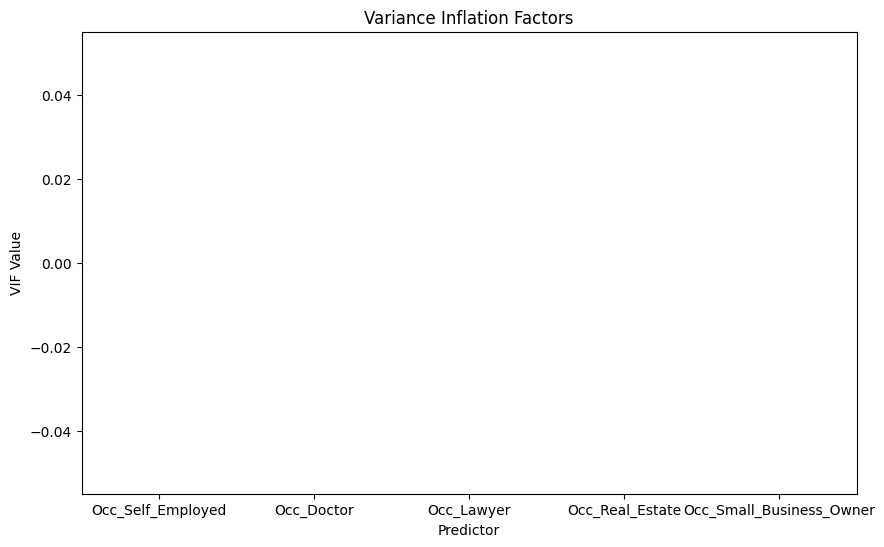

,Occ_Self_Employed,Occ_Doctor,Occ_Lawyer,Occ_Real_Estate,Occ_Small_Business_Owner
VIF,inf,inf,inf,inf,inf


In [ ]:
pr.vif("Tax_Adjustment_Amount ~ Occ_Self_Employed + Occ_Doctor + Occ_Lawyer + Occ_Real_Estate + Occ_Small_Business_Owner", data = df, plot = True)

/tmp/ipykernel_7483/4085410922.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Occupation", y="Tax_Adjustment_Amount", data=df


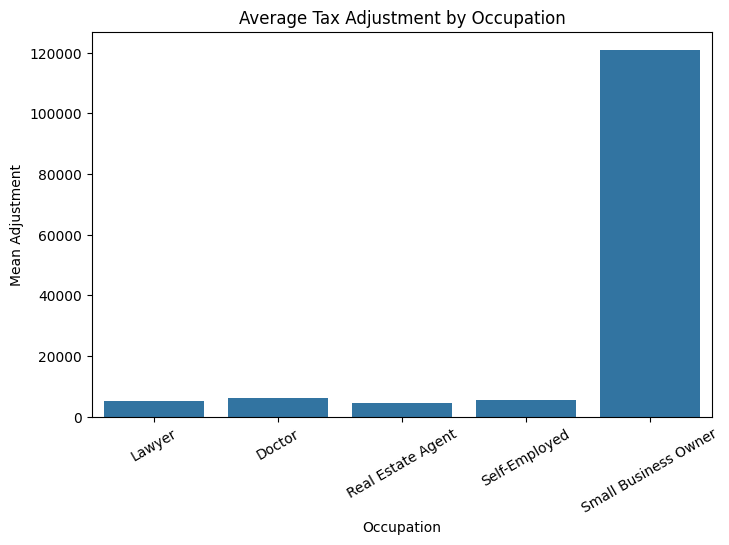

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Occupation", y="Tax_Adjustment_Amount", data=df
, estimator=np.mean, ci=None
            )
plt.title("Average Tax Adjustment by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Mean Adjustment")
plt.xticks(rotation=30)
plt.show()


/tmp/ipykernel_7483/3425377714.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Occupation", y="Tax_Adjustment_Amount", data=df[df["Occupation"] != "Small Business Owner"]


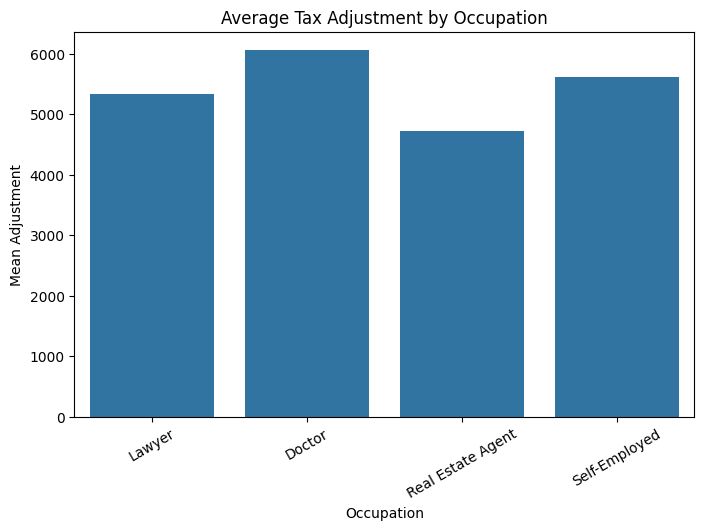

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Occupation", y="Tax_Adjustment_Amount", data=df[df["Occupation"] != "Small Business Owner"]
, estimator=np.mean, ci=None
            )
plt.title("Average Tax Adjustment by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Mean Adjustment")
plt.xticks(rotation=30)
plt.show()


__Avergae Tax Adjustment by Occupation__

Barplots reveal striking differences across occupations.

* Small Business Owners show the highest average adjustments, suggesting this group tends to overstate deductions or underreport income.

* Real Estate Agents and Self-Employed also show elevated adjustments, consistent with industries where record-keeping is less standardized.

* Doctors and Lawyers, by contrast, show much lower average adjustments, reflecting structured financials and detailed record-keeping.

This aligns with prior IRS expectations: occupations with flexible or discretionary expenses face higher audit risk.
$$$$$$$$

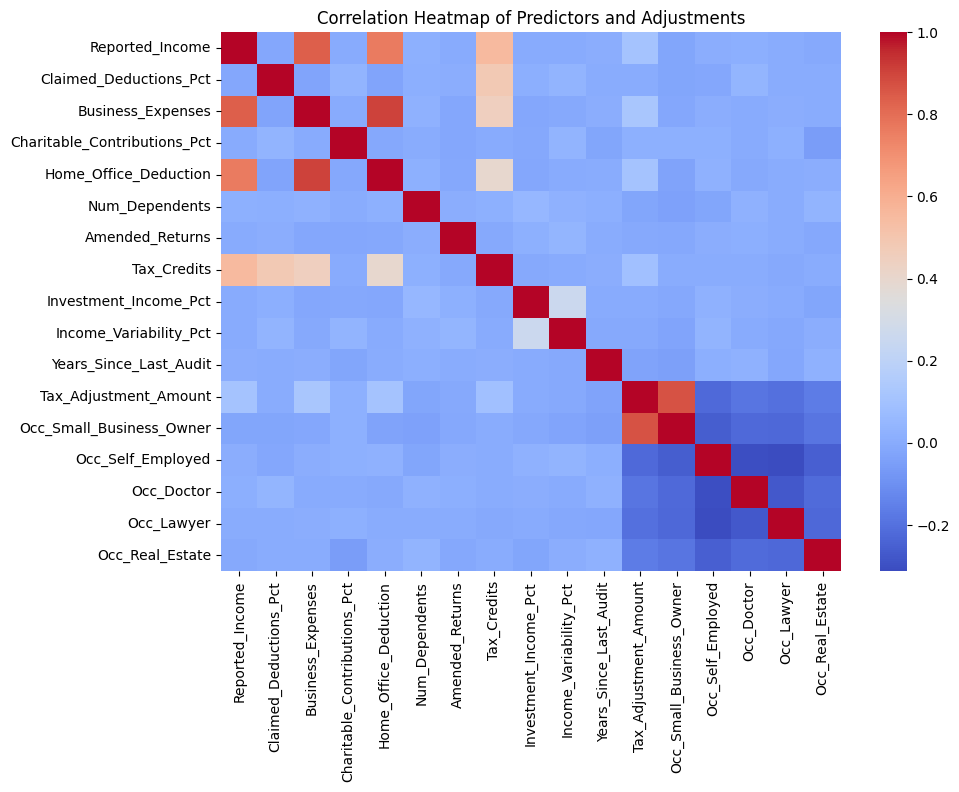

In [ ]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Predictors and Adjustments")
plt.show()


__Heat Map__

The correlation matrix demonstrates that Claimed_Deductions_Pct and Business_Expenses are positively correlated with Tax_Adjustment_Amount, while Years_Since_Last_Audit and Occupation_Doctor show weak or negative relationships. Importantly, no pairs of predictors are highly correlated (no correlation above ~0.8), reducing concerns about multicollinearity. The heatmap provides a useful overview of how each predictor relates to both the target variable and to one another.
$$$$$$$$

$$$$
## __Section 3__


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pregress as pr


In [ ]:
BE = pr.step(formula, data = df)
pr.summary(be)

Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                                coef   std err       t     P>|t|     
Intercept                  1049.9687  1864.942   0.563  0.573000     
Claimed_Deductions_Pct      158.6090   108.652   1.460  0.144000     
Business_Expenses             0.2968     0.122   2.423  0.015000    *
Home_Office_Deduction         1.2154     0.357   3.403  0.001000   **
Tax_Credits                   0.8246     0.396   2.082  0.037000    *
Income_Variability_Pct      121.7675    60.766   2.004  0.045000    *
Occ_Self_Employed        -22910.0000   912.175 -25.111  0.000000  ***
Occ_Doctor               -22260.0000   984.682 -22.611  0.000000  ***
Occ_Lawyer               -23030.0000   961.052 -23.963  0.000000  ***
Occ_Real_Estate          -23720.0000  1091.323 -21.731  0.000000  ***
Occ_Small_Business_Owner  92970.0000  1065.785  87.227  0.000000  ***

Model Statistics:
---------------------------------------

In [ ]:
import numpy as np
import pandas as pd
import pregress as pr
import seaborn as sns
import matplotlib.pyplot as plt

# Load
df = pd.read_csv("suspicious_tax_returns.csv")

# Ensure numeric types
num_cols = [
    "Reported_Income","Claimed_Deductions_Pct","Business_Expenses",
    "Charitable_Contributions_Pct","Home_Office_Deduction","Num_Dependents",
    "Amended_Returns","Tax_Credits","Investment_Income_Pct",
    "Income_Variability_Pct","Years_Since_Last_Audit","Tax_Adjustment_Amount"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Target must be present
df = df.dropna(subset=["Tax_Adjustment_Amount"]).copy()

# Transformations (same rationale you wrote up)
df["Log_Reported_Income"]   = np.log1p(df["Reported_Income"])
df["Log_Business_Expenses"] = np.log1p(df["Business_Expenses"])
df["Expense_to_Income_Ratio"] = np.where(
    df["Reported_Income"] > 0,
    df["Business_Expenses"] / df["Reported_Income"],
    0.0
)

# Manual occupation dummies (baseline = Small Business Owner)
df["Occ_Self_Employed"] = (df["Occupation"] == "Self-Employed").astype(int)
df["Occ_Doctor"]        = (df["Occupation"] == "Doctor").astype(int)
df["Occ_Lawyer"]        = (df["Occupation"] == "Lawyer").astype(int)
df["Occ_Real_Estate"]   = (df["Occupation"] == "Real Estate Agent").astype(int)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Pick candidate predictors to include in the stepwise pool
candidates = [
    "Claimed_Deductions_Pct","Business_Expenses","Reported_Income",
    "Charitable_Contributions_Pct","Home_Office_Deduction","Num_Dependents",
    "Amended_Returns","Tax_Credits","Investment_Income_Pct",
    "Income_Variability_Pct","Years_Since_Last_Audit",
    "Log_Reported_Income","Log_Business_Expenses","Expense_to_Income_Ratio",
    "Occ_Self_Employed","Occ_Doctor","Occ_Lawyer","Occ_Real_Estate"
]
candidates = [c for c in candidates if c in df.columns]

# Modeling dataframe: ONLY target + candidates
df_step = df[["Tax_Adjustment_Amount"] + candidates].dropna().copy()

# ---- STEPWISE (Lab-style) ----
SW = pr.step("Tax_Adjustment_Amount ~ .", data=df_step)   # matches the lab usage
print(pr.summary(SW))                                     # neat single summary


Summary of Regression Analysis:

Coefficients:
------------------------------------------------------
                               coef    std err       t     P>|t|     
Intercept                54910.0000  13000.000   4.213  0.000000  ***
Claimed_Deductions_Pct     290.0419     90.358   3.210  0.001000   **
Business_Expenses            0.2085      0.132   1.579  0.114000     
Home_Office_Deduction        1.2111      0.357   3.388  0.001000   **
Income_Variability_Pct     117.5939     61.057   1.926  0.054000    .
Log_Reported_Income       3925.1009   1304.526   3.009  0.003000   **
Occ_Self_Employed      -116300.0000   1464.666 -79.437  0.000000  ***
Occ_Doctor             -115800.0000   1527.951 -75.768  0.000000  ***
Occ_Lawyer             -116600.0000   1513.096 -77.040  0.000000  ***
Occ_Real_Estate        -117100.0000   1637.780 -71.510  0.000000  ***

Model Statistics:
------------------------------------------------------
R-squared: 0.7797                AIC: 56847.9305
Adj. 

In [ ]:
# Many classes accept the same pr.step call for the backward demo as in the lab.
# If your version allows a 'direction' arg, you could do:
# BE = pr.step("Tax_Adjustment_Amount ~ .", data=df_step, direction="backward")
# print(pr.summary(BE))


In [ ]:
best_sub = pr.bsr("Tax_Adjustment_Amount ~ .", data=df_step)


In [ ]:
print(pr.summary(best_sub))       # summary table
        # Adjusted R^2 / AIC/BIC plots by subset size (single figure)


In [ ]:
pr.plot_bsr(best_sub)

In [ ]:
# If you decide SW is your final model:
final_model = SW
print(pr.summary(final_model))   # include this ONE in the paper

# Residuals (single diagnostic figure is enough)
pr.plot_res(final_model)

# VIF on the selected specification (optional but nice for assumptions)
# If your pregress version supports pr.vif with formula, you can reconstruct:
# Rebuild a formula using the selected columns in final_model if exposed, else skip.
